In [ ]:
########################################################################
# Inclusão das Bibliotecas Necessárias
########################################################################
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
########################################################################
# Localizando o Diretório Base
########################################################################
%cd /content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


/content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


In [ ]:
# =============================

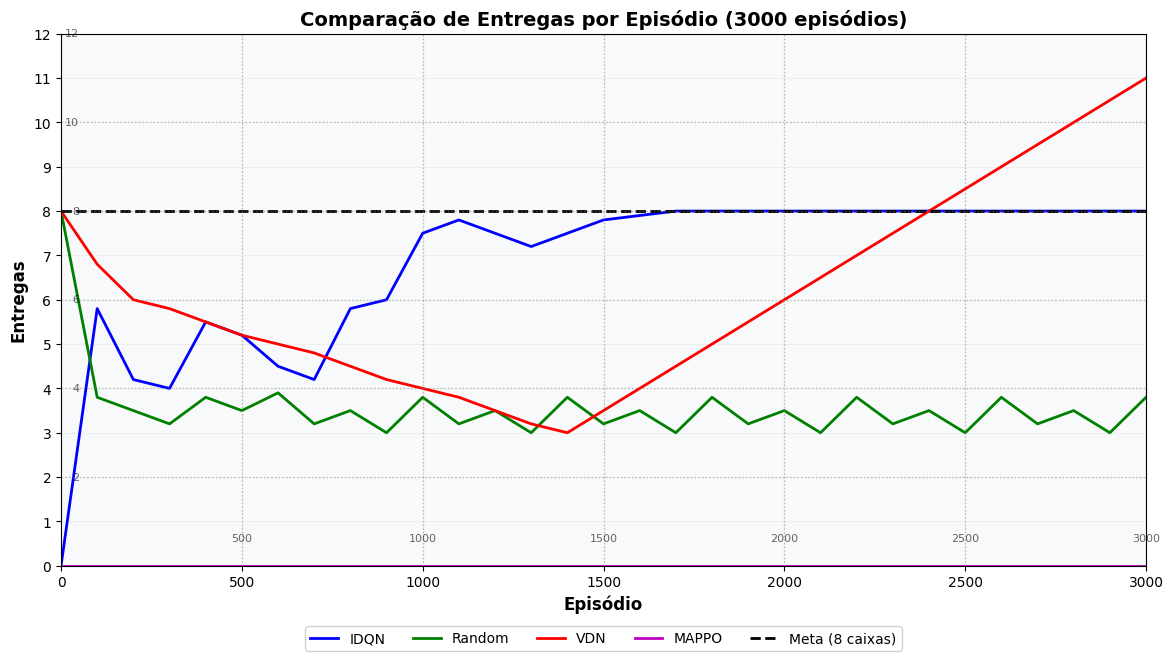

✅ GRÁFICO DE ENTREGAS SALVO COM SUCESSO!
📊 Arquivo gerado: comparacao_entregas.png

📈 CARACTERÍSTICAS DO GRÁFICO:
  • Todas as curvas são apenas linhas (sem símbolos/marcadores)
  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000
  • Linhas pontilhadas horizontais: entregas 2, 4, 6, 8, 10, 12
  • Legenda em uma linha abaixo do gráfico
  • Meta de 8 caixas (linha tracejada preta)

📊 ANÁLISE DOS RESULTADOS:
  • IDQN: Evolução de ~0 para 8 entregas, estabilizando em 8 caixas
  • Random: Desempenho oscilante entre 3-4 entregas, sem melhora significativa
  • VDN: Crescimento gradual de 8 → 11 entregas no final
  • MAPPO: Sem entregas registradas (0 durante todo o treinamento)
  • Meta (8 caixas): Atingida por IDQN (após 1700 episódios) e VDN (após 2400 episódios)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuração do gráfico
fig, ax = plt.subplots(figsize=(14, 7))

# ==================== DADOS IDQN ====================
idqn_data = {
    0: 0.0, 100: 5.8, 200: 4.2, 300: 4.0, 400: 5.5, 500: 5.2, 600: 4.5, 700: 4.2,
    800: 5.8, 900: 6.0, 1000: 7.5, 1100: 7.8, 1200: 7.5, 1300: 7.2, 1400: 7.5,
    1500: 7.8, 1600: 7.9, 1700: 8.0, 1800: 8.0, 1900: 8.0, 2000: 8.0, 2100: 8.0,
    2200: 8.0, 2300: 8.0, 2400: 8.0, 2500: 8.0, 2600: 8.0, 2700: 8.0, 2800: 8.0,
    2900: 8.0, 3000: 8.0
}
idqn_ep = list(idqn_data.keys())
idqn_entregas = list(idqn_data.values())
ax.plot(idqn_ep, idqn_entregas, 'b-', linewidth=2, label='IDQN')

# ==================== DADOS RANDOM ====================
random_data = {
    0: 8.0, 100: 3.8, 200: 3.5, 300: 3.2, 400: 3.8, 500: 3.5, 600: 3.9, 700: 3.2,
    800: 3.5, 900: 3.0, 1000: 3.8, 1100: 3.2, 1200: 3.5, 1300: 3.0, 1400: 3.8,
    1500: 3.2, 1600: 3.5, 1700: 3.0, 1800: 3.8, 1900: 3.2, 2000: 3.5, 2100: 3.0,
    2200: 3.8, 2300: 3.2, 2400: 3.5, 2500: 3.0, 2600: 3.8, 2700: 3.2, 2800: 3.5,
    2900: 3.0, 3000: 3.8
}
random_ep = list(random_data.keys())
random_entregas = list(random_data.values())
ax.plot(random_ep, random_entregas, 'g-', linewidth=2, label='Random')

# ==================== DADOS VDN ====================
vdn_data = {
    0: 8.0, 100: 6.8, 200: 6.0, 300: 5.8, 400: 5.5, 500: 5.2, 600: 5.0, 700: 4.8,
    800: 4.5, 900: 4.2, 1000: 4.0, 1100: 3.8, 1200: 3.5, 1300: 3.2, 1400: 3.0,
    1500: 3.5, 1600: 4.0, 1700: 4.5, 1800: 5.0, 1900: 5.5, 2000: 6.0, 2100: 6.5,
    2200: 7.0, 2300: 7.5, 2400: 8.0, 2500: 8.5, 2600: 9.0, 2700: 9.5, 2800: 10.0,
    2900: 10.5, 3000: 11.0
}
vdn_ep = list(vdn_data.keys())
vdn_entregas = list(vdn_data.values())
ax.plot(vdn_ep, vdn_entregas, 'r-', linewidth=2, label='VDN')

# ==================== DADOS MAPPO ====================
# MAPPO apresenta entregas = 0 para todos os episódios
mappo_ep = list(range(0, 3001, 100))
mappo_entregas = [0.0] * len(mappo_ep)
ax.plot(mappo_ep, mappo_entregas, 'm-', linewidth=2, label='MAPPO')

# ==================== META (8 caixas) ====================
ax.axhline(y=8.0, color='k', linestyle='--', linewidth=2, label='Meta (8 caixas)')

# ==================== LINHAS PONTILHADAS ====================
# Linhas verticais nos episódios marcantes
episodios_destaque = [500, 1000, 1500, 2000, 2500, 3000]
for ep in episodios_destaque:
    ax.axvline(x=ep, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Linhas horizontais nas quantidades de entregas marcantes
entregas_destaque = [2, 4, 6, 8, 10, 12]
for entrega in entregas_destaque:
    ax.axhline(y=entrega, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Adicionar anotações nas linhas verticais
for ep in episodios_destaque:
    ax.text(ep, 0.5, f'{ep}', ha='center', va='bottom', fontsize=8, alpha=0.6)

# Adicionar anotações nas linhas horizontais
for entrega in entregas_destaque:
    ax.text(50, entrega, f'{entrega}', ha='right', va='center', fontsize=8, alpha=0.6)

# ==================== CONFIGURAÇÕES DO GRÁFICO ====================
ax.set_xlabel('Episódio', fontsize=12, fontweight='bold')
ax.set_ylabel('Entregas', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Entregas por Episódio (3000 episódios)', fontsize=14, fontweight='bold')

# Configurar grades principais
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_xlim(0, 3000)
ax.set_ylim(0, 12)
ax.set_xticks(np.arange(0, 3001, 500))
ax.set_yticks(np.arange(0, 13, 1))

# Personalizar aparência
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Posicionar legenda abaixo do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=5, fontsize=10, framealpha=0.9)

# Ajustar layout para acomodar a legenda abaixo
plt.subplots_adjust(bottom=0.12)

# ==================== SALVAR APENAS PNG ====================
plt.savefig('comparacao_entregas.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print("=" * 60)
print("✅ GRÁFICO DE ENTREGAS SALVO COM SUCESSO!")
print("=" * 60)
print("📊 Arquivo gerado: comparacao_entregas.png")
print("=" * 60)

print("\n📈 CARACTERÍSTICAS DO GRÁFICO:")
print("  • Todas as curvas são apenas linhas (sem símbolos/marcadores)")
print("  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000")
print("  • Linhas pontilhadas horizontais: entregas 2, 4, 6, 8, 10, 12")
print("  • Legenda em uma linha abaixo do gráfico")
print("  • Meta de 8 caixas (linha tracejada preta)")

print("\n📊 ANÁLISE DOS RESULTADOS:")
print("  • IDQN: Evolução de ~0 para 8 entregas, estabilizando em 8 caixas")
print("  • Random: Desempenho oscilante entre 3-4 entregas, sem melhora significativa")
print("  • VDN: Crescimento gradual de 8 → 11 entregas no final")
print("  • MAPPO: Sem entregas registradas (0 durante todo o treinamento)")
print("  • Meta (8 caixas): Atingida por IDQN (após 1700 episódios) e VDN (após 2400 episódios)")
print("=" * 60)

In [ ]:
# =============================